# Disease Prediction Model

## Objective

The objective of this notebook is to build a machine learning model
that predicts a disease based on the symptoms provided by the patient.

The model will use the 132 binary symptom features from the Training dataset
and predict one of the 41 disease classes.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Training.csv")

df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [2]:
X = df.drop(columns=["prognosis"])
y = df["prognosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4920, 132)
y shape: (4920,)


In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Number of classes:", len(label_encoder.classes_))
print("First 10 classes:", label_encoder.classes_[:10])

Number of classes: 41
First 10 classes: ['(vertigo) Paroymsal  Positional Vertigo' 'AIDS' 'Acne'
 'Alcoholic hepatitis' 'Allergy' 'Arthritis' 'Bronchial Asthma'
 'Cervical spondylosis' 'Chicken pox' 'Chronic cholestasis']


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3936, 132)
X_test : (984, 132)
y_train: (3936,)
y_test : (984,)


In [5]:
from sklearn.svm import SVC

svc_model = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

svc_model.fit(X_train, y_train)

print("SVC model training completed.")

SVC model training completed.


In [6]:
y_pred = svc_model.predict(X_test)

print("Predictions generated:", len(y_pred))
print("Actual values:", len(y_test))

Predictions generated: 984
Actual values: 984


In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("SVC Accuracy:", accuracy)
print("SVC Accuracy (%):", accuracy * 100)

SVC Accuracy: 1.0
SVC Accuracy (%): 100.0


In [8]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.00        24
                           

## Confusion Matrix

The confusion matrix shows how many samples from each disease
were correctly or incorrectly classified by the model.

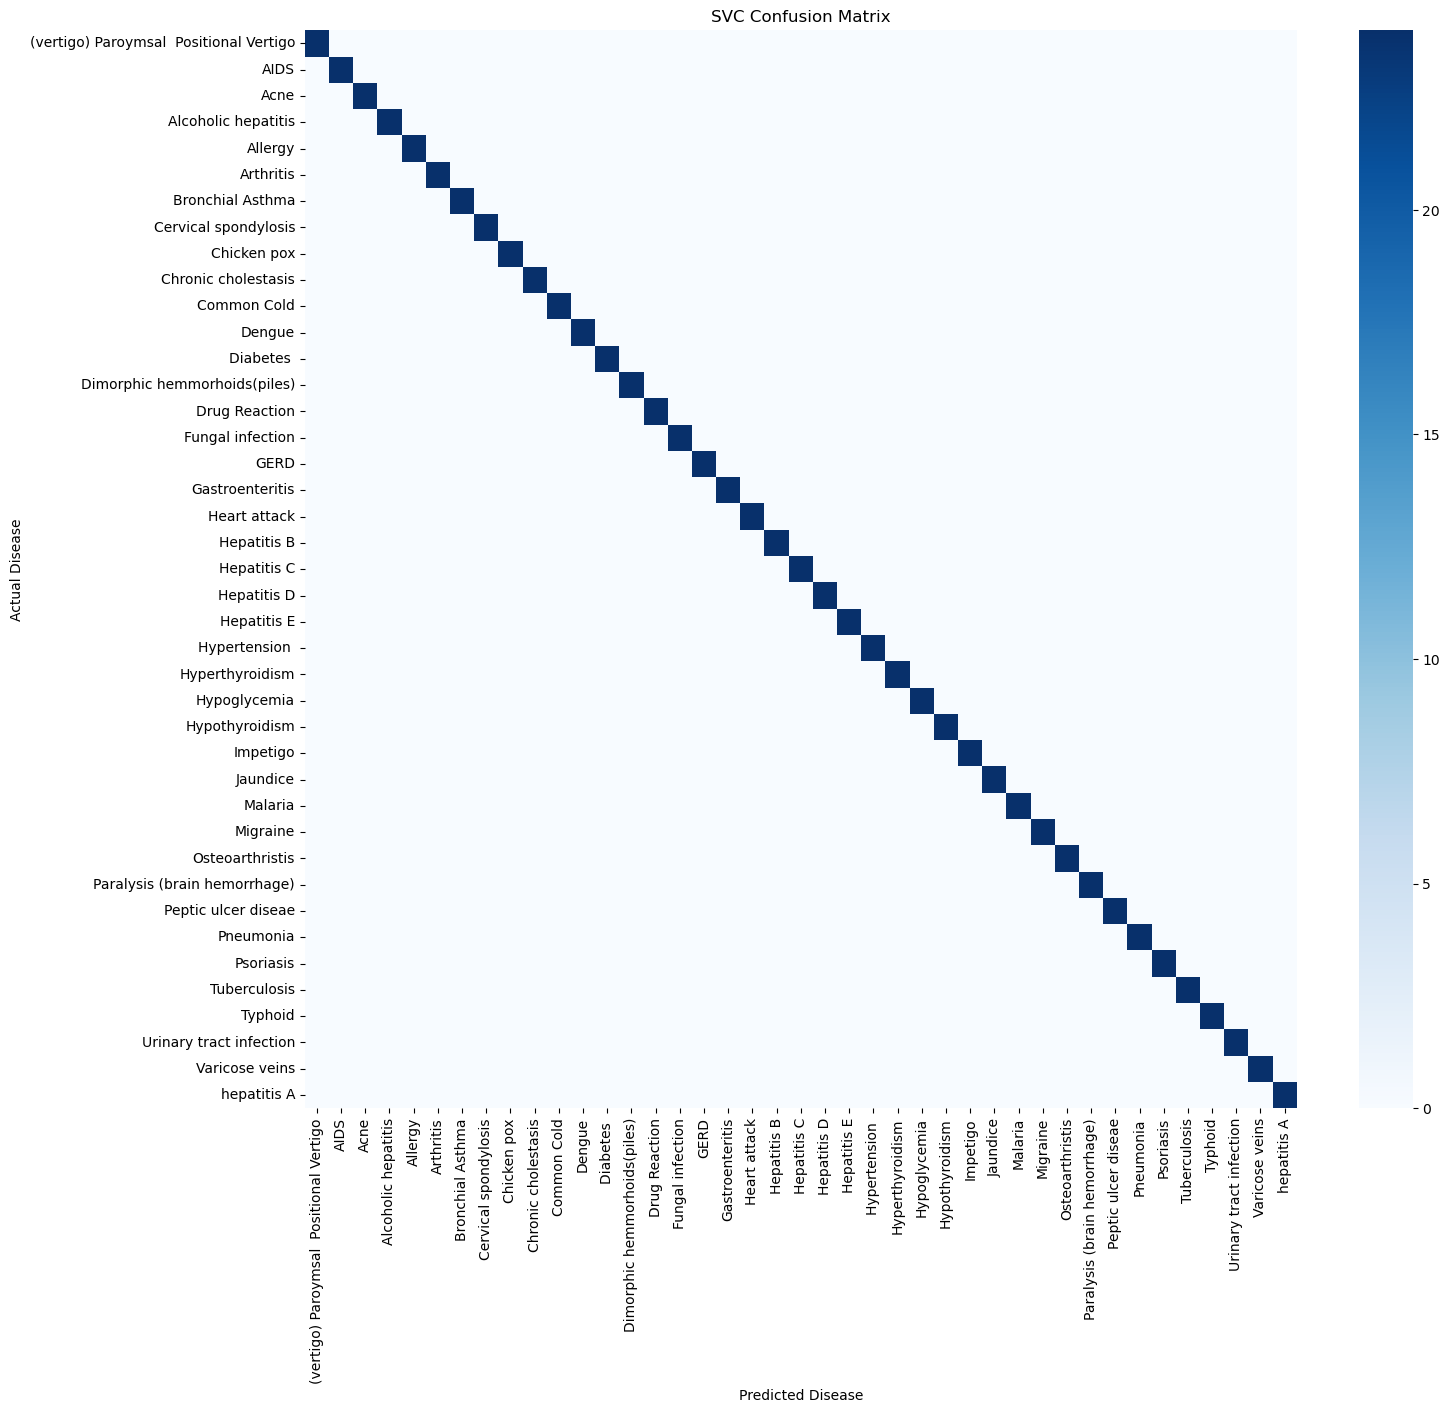

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.title("SVC Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## Cross-Validation

Cross-validation is used to evaluate the model across multiple
different train-validation splits instead of relying on a single
train-test split.

In [10]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    svc_model,
    X,
    y_encoded,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation scores: [1. 1. 1. 1. 1.]
Mean CV accuracy: 1.0
Standard deviation: 0.0


Save the trained model

In [11]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder ready.")

Models folder ready.


In [12]:
import joblib

joblib.dump(svc_model, "../models/best_model.pkl")

print("Disease prediction model saved successfully.")

Disease prediction model saved successfully.


In [13]:
joblib.dump(label_encoder, "../models/disease_encoder.pkl")

print("Disease label encoder saved successfully.")

Disease label encoder saved successfully.


In [14]:
loaded_model = joblib.load("../models/best_model.pkl")
loaded_encoder = joblib.load("../models/disease_encoder.pkl")

print("Model loaded:", type(loaded_model).__name__)
print("Encoder loaded:", type(loaded_encoder).__name__)

Model loaded: SVC
Encoder loaded: LabelEncoder


In [15]:
sample = X_test.iloc[0:1]

predicted_label = loaded_model.predict(sample)[0]
predicted_disease = loaded_encoder.inverse_transform([predicted_label])[0]

actual_label = y_test[0]
actual_disease = loaded_encoder.inverse_transform([actual_label])[0]

print("Predicted Disease:", predicted_disease)
print("Actual Disease:", actual_disease)

Predicted Disease: Hypertension 
Actual Disease: Hypertension 
